In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
dataset_path = "/content/drive/MyDrive/ML_Assignment/Crop_Dataset"

print(dataset_path)

/content/drive/MyDrive/ML_Assignment/Crop_Dataset


In [7]:
import os

print(os.listdir(dataset_path))

['Sunflower', 'Wheat', 'Maize', 'Paddy', 'Sugarcane']


In [8]:
import os

for class_name in sorted(os.listdir(dataset_path)):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ]

        print(f"{class_name}: {len(images)} images")

Maize: 71 images
Paddy: 67 images
Sugarcane: 65 images
Sunflower: 319 images
Wheat: 72 images


In [ ]:
import os
import random
import shutil

source_path = dataset_path

split_path = "/content/drive/MyDrive/ML_Assignment/Crop_Dataset_Split"

classes = ["Sunflower", "Wheat", "Maize", "Paddy", "Sugarcane"]

random.seed(42)

for split in ["train", "validation", "test"]:
    for class_name in classes:
        os.makedirs(
            os.path.join(split_path, split, class_name),
            exist_ok=True
        )

print("Folders created successfully.")

Folders created successfully.


In [ ]:
for class_name in classes:

    source_class_path = os.path.join(source_path, class_name)

    # Get image files
    images = [
        f for f in os.listdir(source_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    random.shuffle(images)
    images = images[:65]

    train_images = images[:46]
    validation_images = images[46:56]
    test_images = images[56:65]

    for image in train_images:
        shutil.copy2(
            os.path.join(source_class_path, image),
            os.path.join(split_path, "train", class_name, image)
        )

    for image in validation_images:
        shutil.copy2(
            os.path.join(source_class_path, image),
            os.path.join(split_path, "validation", class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(source_class_path, image),
            os.path.join(split_path, "test", class_name, image)
        )

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(validation_images)}, "
        f"Test={len(test_images)}"
    )

Sunflower: Train=46, Validation=10, Test=9
Wheat: Train=46, Validation=10, Test=9
Maize: Train=46, Validation=10, Test=9
Paddy: Train=46, Validation=10, Test=9
Sugarcane: Train=46, Validation=10, Test=9


In [11]:
import tensorflow as tf

train_path = os.path.join(split_path, "train")
validation_path = os.path.join(split_path, "validation")
test_path = os.path.join(split_path, "test")

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=16,
    shuffle=True,
    seed=42
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=(224, 224),
    batch_size=16,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=16,
    shuffle=False
)

Found 244 files belonging to 5 classes.
Found 58 files belonging to 5 classes.
Found 53 files belonging to 5 classes.


In [12]:
import shutil
import os

# Delete the previous split dataset completely
if os.path.exists(split_path):
    shutil.rmtree(split_path)

print("Old split dataset deleted.")

Old split dataset deleted.


In [13]:
for split in ["train", "validation", "test"]:
    for class_name in classes:
        os.makedirs(
            os.path.join(split_path, split, class_name),
            exist_ok=True
        )

print("Fresh train/validation/test folders created.")

Fresh train/validation/test folders created.


In [ ]:
import random
import shutil
import os

random.seed(42)

for class_name in classes:

    source_class_path = os.path.join(source_path, class_name)

    images = [
        f for f in os.listdir(source_class_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
    ]

    random.shuffle(images)
    images = images[:65]

    train_images = images[:46]
    validation_images = images[46:56]
    test_images = images[56:65]

    for image in train_images:
        shutil.copy2(
            os.path.join(source_class_path, image),
            os.path.join(split_path, "train", class_name, image)
        )

    for image in validation_images:
        shutil.copy2(
            os.path.join(source_class_path, image),
            os.path.join(split_path, "validation", class_name, image)
        )

    for image in test_images:
        shutil.copy2(
            os.path.join(source_class_path, image),
            os.path.join(split_path, "test", class_name, image)
        )

    print(
        f"{class_name}: "
        f"Train={len(train_images)}, "
        f"Validation={len(validation_images)}, "
        f"Test={len(test_images)}"
    )

Sunflower: Train=46, Validation=10, Test=9
Wheat: Train=46, Validation=10, Test=9
Maize: Train=46, Validation=10, Test=9
Paddy: Train=46, Validation=10, Test=9
Sugarcane: Train=46, Validation=10, Test=9


In [15]:
for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    for class_name in classes:
        folder = os.path.join(split_path, split, class_name)

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))
        ])

        print(f"{class_name}: {count}")


TRAIN
Sunflower: 46
Wheat: 46
Maize: 46
Paddy: 46
Sugarcane: 46

VALIDATION
Sunflower: 10
Wheat: 10
Maize: 10
Paddy: 10
Sugarcane: 10

TEST
Sunflower: 9
Wheat: 9
Maize: 9
Paddy: 9
Sugarcane: 9


In [16]:
import tensorflow as tf

train_path = os.path.join(split_path, "train")
validation_path = os.path.join(split_path, "validation")
test_path = os.path.join(split_path, "test")

train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=(224, 224),
    batch_size=16,
    shuffle=True,
    seed=42
)

validation_data = tf.keras.utils.image_dataset_from_directory(
    validation_path,
    image_size=(224, 224),
    batch_size=16,
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=(224, 224),
    batch_size=16,
    shuffle=False
)


Found 230 files belonging to 5 classes.
Found 50 files belonging to 5 classes.
Found 45 files belonging to 5 classes.


In [17]:
print("Classes:", train_data.class_names)

Classes: ['Maize', 'Paddy', 'Sugarcane', 'Sunflower', 'Wheat']


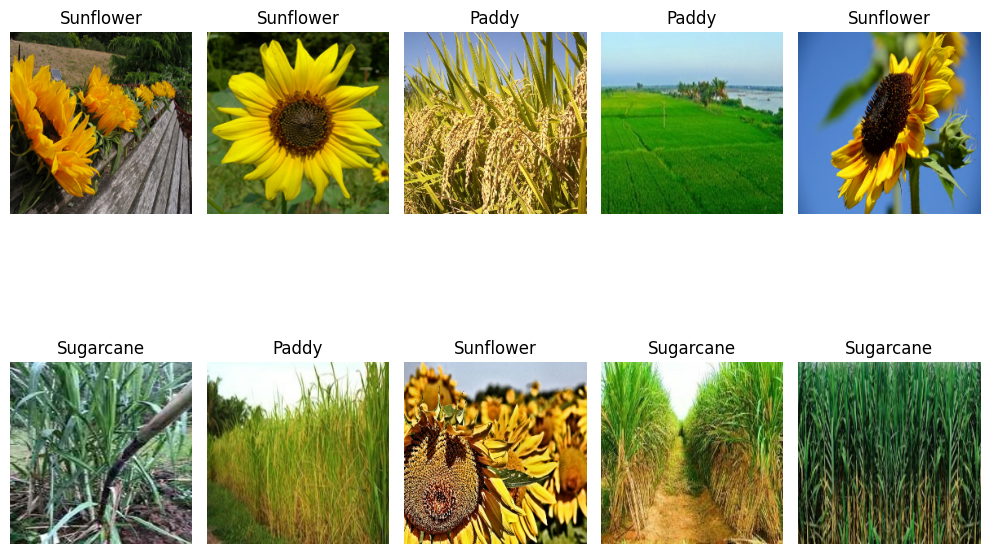

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for images, labels in train_data.take(1):

    for i in range(10):
        ax = plt.subplot(2, 5, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_data.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [19]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [20]:
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [22]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    data_augmentation,

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation="relu"),

    Dropout(0.5),

    Dense(5, activation="softmax")
])

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Rescaling,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)

model = Sequential([
    Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # Convert pixel values from 0-255 to approximately -1 to 1
    Rescaling(1./127.5, offset=-1),

    # Pretrained MobileNetV2
    base_model,

    # Convert feature maps into a feature vector
    GlobalAveragePooling2D(),

    # Classification layer
    Dense(128, activation="relu"),

    # Reduce overfitting
    Dropout(0.5),

    # 5 crop classes
    Dense(5, activation="softmax")
])

In [27]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
Input(shape=(224, 224, 3))

<KerasTensor shape=(None, 224, 224, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_166>

In [31]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 200ms/step - accuracy: 0.2130 - loss: 2.0360 - val_accuracy: 0.1800 - val_loss: 1.6261
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.2739 - loss: 1.7032 - val_accuracy: 0.3800 - val_loss: 1.4371
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.3217 - loss: 1.5607 - val_accuracy: 0.5200 - val_loss: 1.3078
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - accuracy: 0.3957 - loss: 1.4547 - val_accuracy: 0.5000 - val_loss: 1.2113
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 143ms/step - accuracy: 0.4522 - loss: 1.3098 - val_accuracy: 0.6600 - val_loss: 1.1366
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.5391 - loss: 1.2049 - val_accuracy: 0.6600 - val_loss: 1.0719
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.5870 - loss: 1.0876 - val_accuracy: 0.7000 - val_loss: 1.0198
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6217 - loss: 1.0174 - val_accuracy: 0.740

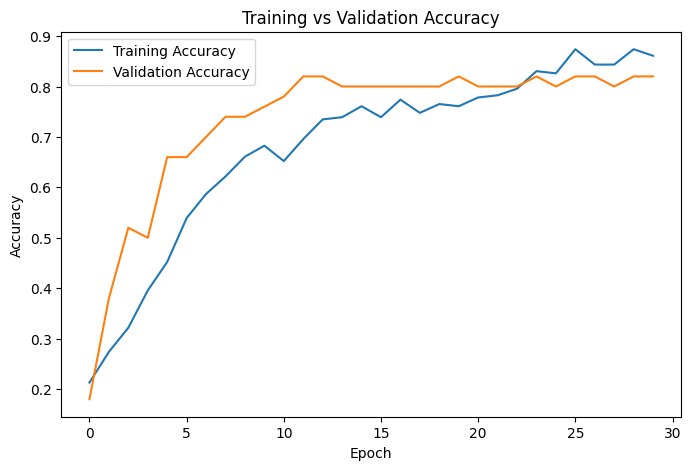

In [33]:
import matplotlib.pyplot as plt

# Training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

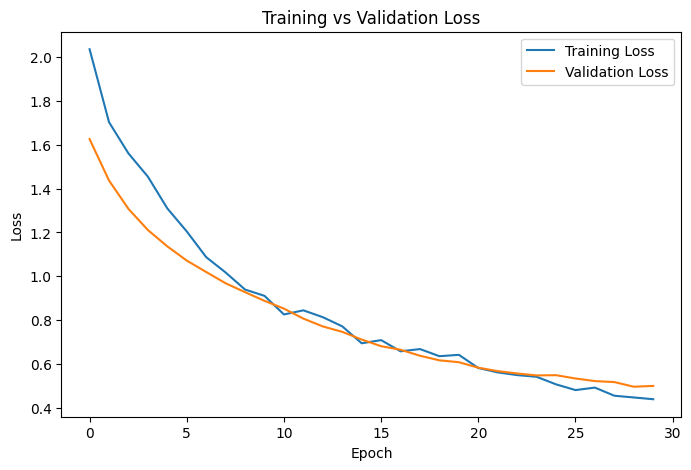

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [35]:
test_loss, test_accuracy = model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 365ms/step - accuracy: 0.8000 - loss: 0.6491
Test Loss: 0.6490621566772461
Test Accuracy: 0.800000011920929


In [36]:
import numpy as np

y_true = []
y_pred = []

for images, labels in test_data:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("True labels:", y_true)
print("Predicted labels:", y_pred)

True labels: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 3 3 3 3 3 3 3 3 3 4
 4 4 4 4 4 4 4 4]
Predicted labels: [1 0 0 0 2 0 0 0 2 1 1 4 1 1 1 1 1 4 2 2 2 2 0 0 2 2 0 3 3 3 3 3 3 3 3 3 4
 4 4 4 4 4 4 1 4]


In [37]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=train_data.class_names,
    digits=4
)

print(report)

              precision    recall  f1-score   support

       Maize     0.6667    0.6667    0.6667         9
       Paddy     0.7778    0.7778    0.7778         9
   Sugarcane     0.7500    0.6667    0.7059         9
   Sunflower     1.0000    1.0000    1.0000         9
       Wheat     0.8000    0.8889    0.8421         9

    accuracy                         0.8000        45
   macro avg     0.7989    0.8000    0.7985        45
weighted avg     0.7989    0.8000    0.7985        45



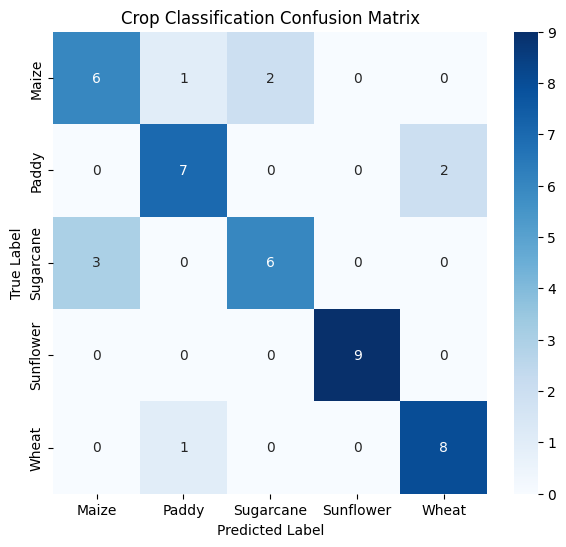

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_data.class_names,
    yticklabels=train_data.class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Crop Classification Confusion Matrix")
plt.show()

In [39]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=train_data.class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

       Maize     0.6667    0.6667    0.6667         9
       Paddy     0.7778    0.7778    0.7778         9
   Sugarcane     0.7500    0.6667    0.7059         9
   Sunflower     1.0000    1.0000    1.0000         9
       Wheat     0.8000    0.8889    0.8421         9

    accuracy                         0.8000        45
   macro avg     0.7989    0.8000    0.7985        45
weighted avg     0.7989    0.8000    0.7985        45



In [40]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

class_names = train_data.class_names

def predict_crop(image_path):

    # Load and resize image
    image = load_img(
        image_path,
        target_size=(224, 224)
    )

    # Convert image to NumPy array
    image_array = img_to_array(image)

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Make prediction
    probabilities = model.predict(image_array, verbose=0)[0]

    # Find class with highest probability
    predicted_index = np.argmax(probabilities)

    predicted_class = class_names[predicted_index]
    confidence = probabilities[predicted_index] * 100

    print("Predicted Crop:", predicted_class)
    print("Confidence:", f"{confidence:.2f}%")

    return predicted_class, confidence

In [41]:
import os

sample_folder = os.path.join(
    source_path,
    "Sunflower"
)

sample_image = os.listdir(sample_folder)[0]

sample_path = os.path.join(
    sample_folder,
    sample_image
)

print(sample_path)

/content/drive/MyDrive/ML_Assignment/Crop_Dataset/Sunflower/14889779907_3d401bbac7_m.jpg
